# Super-Resolution com Stable Diffusion (Local/WSL)

Este notebook implementa o pipeline de Super-Resolução utilizando o modelo `stable-diffusion-x4-upscaler`.

**Configuração do Experimento**
* **Dataset:** Set14 (Escalas: x2, x3, x4)
* **Modelo:** stabilityai/stable-diffusion-x4-upscaler

---


## 1. Verificação de Ambiente


In [11]:
import torch
from pathlib import Path
import os
import warnings

# Suprimir warnings irrelevantes para apresentação
warnings.filterwarnings("ignore")

print("--- Verificação de Hardware e Dados ---")

# 1. Verificar GPU
cuda_available = torch.cuda.is_available()
print(f"CUDA Disponível: {cuda_available}")

if cuda_available:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Versão CUDA: {torch.version.cuda}")
    print(f"Memória Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = "cuda"
else:
    print("Aviso: GPU não detectada. Executando em CPU.")
    device = "cpu"

# 2. Verificar Dataset
ROOT_DIR = Path("./Set14").resolve()

if ROOT_DIR.exists():
    for scale in [2, 3, 4]:
        lr_dir = ROOT_DIR / f"image_SRF_{scale}"
        if lr_dir.exists():
            lr_files = list(lr_dir.glob("*_LR.png"))
            hr_files = list(lr_dir.glob("*_HR.png"))
            print(f"Dataset SRF_{scale}: {len(lr_files)} imagens LR / {len(hr_files)} imagens HR")
        else:
            print(f"Dataset SRF_{scale}: Não encontrado")
else:
    print("Erro: Diretório do dataset não encontrado.")

# 3. Verificar Bibliotecas Essenciais
try:
    import diffusers
    import transformers
    from skimage.metrics import peak_signal_noise_ratio
    print("Bibliotecas: Carregadas com sucesso.")
except ImportError as e:
    print(f"Erro de dependência: {e}")

print(f"Dispositivo selecionado: {device.upper()}")


--- Verificação de Hardware e Dados ---
CUDA Disponível: True
GPU: NVIDIA GeForce RTX 5070
Versão CUDA: 12.8
Memória Total: 12.82 GB
Dataset SRF_2: 14 imagens LR / 14 imagens HR
Dataset SRF_3: 14 imagens LR / 14 imagens HR
Dataset SRF_4: 14 imagens LR / 14 imagens HR
Bibliotecas: Carregadas com sucesso.
Dispositivo selecionado: CUDA


## 2. Configuração do Pipeline


In [2]:
from diffusers import StableDiffusionUpscalePipeline
from PIL import Image

print("Inicializando pipeline do Stable Diffusion x4 Upscaler...")

model_id = "stabilityai/stable-diffusion-x4-upscaler"
# Utilizar float32 para garantir estabilidade numérica do VAE
dtype = torch.float32

pipe = StableDiffusionUpscalePipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    safety_checker=None
)

pipe = pipe.to(device)

# Garantir precisão float32 nos componentes críticos para evitar artefatos pretos (NaN)
pipe.vae = pipe.vae.float()
pipe.unet = pipe.unet.float()
pipe.text_encoder = pipe.text_encoder.float()

# Otimizações de memória
pipe.enable_attention_slicing()

if device == "cuda":
    try:
        pipe.enable_vae_tiling()
        print("Otimização: VAE Tiling ativado.")
    except Exception:
        pass

print("Pipeline carregado.")


Inicializando pipeline do Stable Diffusion x4 Upscaler...


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 29.53it/s]


Otimização: VAE Tiling ativado.
Pipeline carregado.


In [3]:
def upscale_set14_for_scale(
    root_dir: Path,
    scale: int,
    device: str = "cuda",
    prompt: str = "",
    num_inference_steps: int = 40,
    match_hr_size: bool = True,
):
    """
    Processa o dataset Set14 para uma determinada escala de super-resolução.
    
    Args:
        root_dir: Diretório raiz do dataset.
        scale: Fator de escala (2, 3 ou 4).
        device: Dispositivo de processamento.
        prompt: Prompt de texto para o modelo de difusão.
        num_inference_steps: Número de passos de denoising.
        match_hr_size: Se True, redimensiona a saída para coincidir com a dimensão HR.
    """
    lr_dir = root_dir / f"image_SRF_{scale}"
    out_dir = root_dir / f"results_SR_x{scale}"
    out_dir.mkdir(parents=True, exist_ok=True)
    
    lr_paths = sorted(lr_dir.glob(f"*SRF_{scale}_LR.png"))
    if not lr_paths:
        raise RuntimeError(f"Nenhuma imagem LR encontrada em {lr_dir}")
    
    pairs = []
    for lr_path in lr_paths:
        base = lr_path.name.replace("_LR.png", "")
        hr_name = f"{base}_HR.png".replace("_LR_HR", "_HR")
        hr_path = lr_dir / hr_name
        if hr_path.exists():
            pairs.append((lr_path, hr_path))
    
    print(f"--- Processando Escala {scale}x ---")
    print(f"Entrada: {lr_dir}")
    print(f"Saída:   {out_dir}")
    print(f"Total de imagens: {len(pairs)}")
    
    import numpy as np
    
    for idx, (lr_path, hr_path) in enumerate(pairs, 1):
        print(f"[{idx}/{len(pairs)}] Processando: {lr_path.name}")
        
        lr_image = Image.open(lr_path).convert("RGB")
        hr_image = Image.open(hr_path).convert("RGB")
        
        # Inferência sem autocast para manter estabilidade float32
        with torch.no_grad():
            result = pipe(
                prompt=prompt,
                image=lr_image,
                num_inference_steps=num_inference_steps,
                guidance_scale=0.0,
            )
        
        sr_image = result.images[0]
        
        # Validação de integridade da imagem
        sr_array = np.array(sr_image)
        if sr_array.max() == 0:
            print("Aviso: Imagem gerada inválida (pixels pretos).")
        
        # Ajuste dimensional para métricas comparativas
        if match_hr_size:
            sr_image = sr_image.resize(hr_image.size, Image.BICUBIC)
        
        stem_base = lr_path.name.replace("_LR.png", "")
        out_name = f"{stem_base}_SRx{scale}.png"
        out_path = out_dir / out_name
        sr_image.save(out_path)
    
    print(f"Processamento de escala {scale}x finalizado.")


## 3. Execução do Pipeline


In [4]:
# Escala 2x
upscale_set14_for_scale(
    root_dir=ROOT_DIR,
    scale=2,
    device=device,
    num_inference_steps=40
)


--- Processando Escala 2x ---
Entrada: /mnt/c/Users/Pichau/Documents/Trabalhos Faculdade/MC949_Visao_Computacional/Trabalho 4/Set14/image_SRF_2
Saída:   /mnt/c/Users/Pichau/Documents/Trabalhos Faculdade/MC949_Visao_Computacional/Trabalho 4/Set14/results_SR_x2
Total de imagens: 14
[1/14] Processando: img_001_SRF_2_LR.png


100%|██████████| 40/40 [00:09<00:00,  4.26it/s]


[2/14] Processando: img_002_SRF_2_LR.png


100%|██████████| 40/40 [00:19<00:00,  2.06it/s]


[3/14] Processando: img_003_SRF_2_LR.png


...

[13/14] Processando: img_013_SRF_2_LR.png


100%|██████████| 40/40 [00:12<00:00,  3.15it/s]


[14/14] Processando: img_014_SRF_2_LR.png


100%|██████████| 40/40 [00:08<00:00,  4.69it/s]


Processamento de escala 2x finalizado.


In [5]:
# Escala 3x
upscale_set14_for_scale(
    root_dir=ROOT_DIR,
    scale=3,
    device=device,
    num_inference_steps=40
)


--- Processando Escala 3x ---
Entrada: /mnt/c/Users/Pichau/Documents/Trabalhos Faculdade/MC949_Visao_Computacional/Trabalho 4/Set14/image_SRF_3
Saída:   /mnt/c/Users/Pichau/Documents/Trabalhos Faculdade/MC949_Visao_Computacional/Trabalho 4/Set14/results_SR_x3
Total de imagens: 14
[1/14] Processando: img_001_SRF_3_LR.png


100%|██████████| 40/40 [00:04<00:00,  9.57it/s]


[2/14] Processando: img_002_SRF_3_LR.png


100%|██████████| 40/40 [00:10<00:00,  3.79it/s]


[3/14] Processando: img_003_SRF_3_LR.png


...

[13/14] Processando: img_013_SRF_3_LR.png


100%|██████████| 40/40 [00:05<00:00,  6.95it/s]


[14/14] Processando: img_014_SRF_3_LR.png


100%|██████████| 40/40 [00:03<00:00, 11.02it/s]


Processamento de escala 3x finalizado.


In [6]:
# Escala 4x
upscale_set14_for_scale(
    root_dir=ROOT_DIR,
    scale=4,
    device=device,
    num_inference_steps=40
)


--- Processando Escala 4x ---
Entrada: /mnt/c/Users/Pichau/Documents/Trabalhos Faculdade/MC949_Visao_Computacional/Trabalho 4/Set14/image_SRF_4
Saída:   /mnt/c/Users/Pichau/Documents/Trabalhos Faculdade/MC949_Visao_Computacional/Trabalho 4/Set14/results_SR_x4
Total de imagens: 14
[1/14] Processando: img_001_SRF_4_LR.png


100%|██████████| 40/40 [00:02<00:00, 15.53it/s]


[2/14] Processando: img_002_SRF_4_LR.png


100%|██████████| 40/40 [00:04<00:00,  9.68it/s]


[3/14] Processando: img_003_SRF_4_LR.png


...

[13/14] Processando: img_013_SRF_4_LR.png


100%|██████████| 40/40 [00:03<00:00, 11.97it/s]


[14/14] Processando: img_014_SRF_4_LR.png


100%|██████████| 40/40 [00:02<00:00, 17.08it/s]


Processamento de escala 4x finalizado.


## 4. Avaliação Quantitativa (PSNR e SSIM)


In [7]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import pandas as pd

def evaluate_scale(root_dir: Path, scale: int):
    """
    Calcula as métricas PSNR e SSIM comparando as imagens geradas (SR) com as originais (HR).
    """
    hr_dir = root_dir / f"image_SRF_{scale}"
    sr_dir = root_dir / f"results_SR_x{scale}"
    
    if not sr_dir.exists():
        print(f"Diretório de resultados não encontrado: {sr_dir}")
        return None
    
    hr_paths = sorted(hr_dir.glob(f"*SRF_{scale}_HR.png"))
    results = []
    
    print(f"--- Avaliação de Métricas: Escala {scale}x ---")
    
    for hr_path in hr_paths:
        base = hr_path.name.replace("_HR.png", "")
        sr_name = f"{base}_SRx{scale}.png"
        sr_path = sr_dir / sr_name
        
        if not sr_path.exists():
            continue
        
        hr = np.array(Image.open(hr_path).convert("RGB"))
        sr = np.array(Image.open(sr_path).convert("RGB"))
        
        if hr.shape != sr.shape:
            print(f"Aviso: Dimensões incompatíveis para {hr_path.name}")
            continue
        
        psnr = peak_signal_noise_ratio(hr, sr, data_range=255)
        ssim = structural_similarity(hr, sr, channel_axis=2, data_range=255)
        
        results.append({
            "Imagem": hr_path.name,
            "PSNR (dB)": psnr,
            "SSIM": ssim,
        })
    
    if not results:
        return None
    
    df = pd.DataFrame(results)
    
    print(f"Média PSNR: {df['PSNR (dB)'].mean():.2f} dB")
    print(f"Média SSIM: {df['SSIM'].mean():.4f}")
    
    return df


In [8]:
df_2x = evaluate_scale(ROOT_DIR, 2)
df_3x = evaluate_scale(ROOT_DIR, 3)
df_4x = evaluate_scale(ROOT_DIR, 4)


--- Avaliação de Métricas: Escala 2x ---
Média PSNR: 25.71 dB
Média SSIM: 0.7569
--- Avaliação de Métricas: Escala 3x ---
Média PSNR: 23.50 dB
Média SSIM: 0.6429
--- Avaliação de Métricas: Escala 4x ---
Média PSNR: 22.37 dB
Média SSIM: 0.5746


## 5. Visualização de Resultados


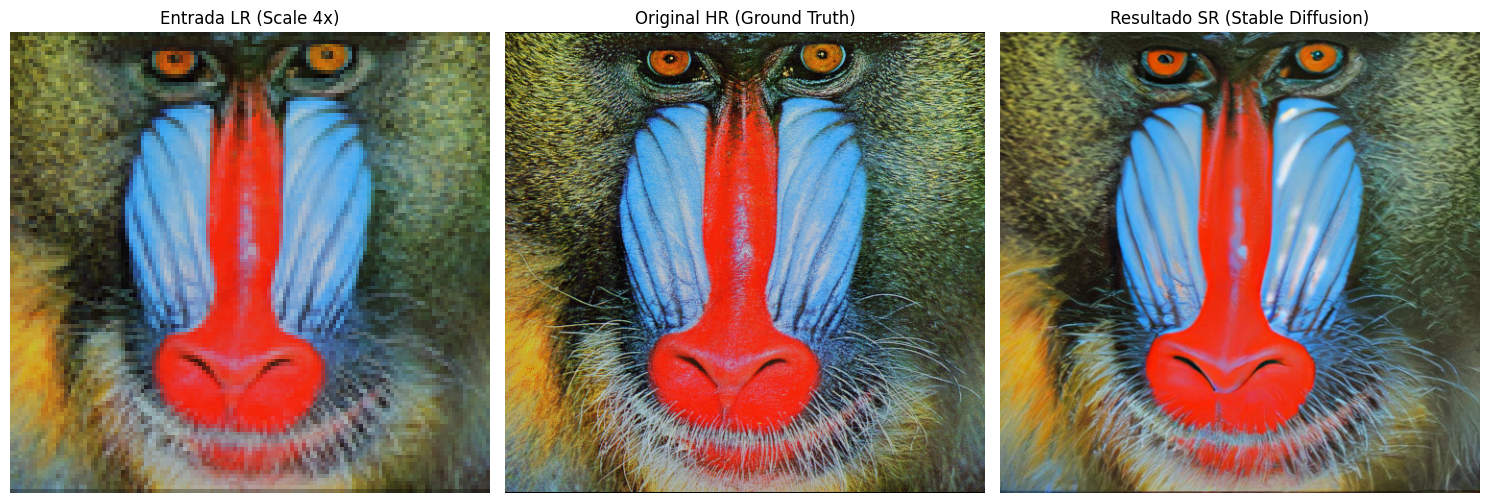

In [9]:
import matplotlib.pyplot as plt

def visualize_comparison(root_dir: Path, scale: int, image_idx: int = 0):
    """
    Exibe comparação visual: Baixa Resolução (LR), Alta Resolução (HR) e Super-Resolução (SR).
    """
    lr_dir = root_dir / f"image_SRF_{scale}"
    sr_dir = root_dir / f"results_SR_x{scale}"
    
    lr_paths = sorted(lr_dir.glob(f"*SRF_{scale}_LR.png"))
    if not lr_paths or image_idx >= len(lr_paths):
        print("Imagem não encontrada para visualização.")
        return
    
    lr_path = lr_paths[image_idx]
    base = lr_path.name.replace("_LR.png", "")
    hr_path = lr_dir / f"{base}_HR.png".replace("_LR_HR", "_HR")
    sr_path = sr_dir / f"{base}_SRx{scale}.png"
    
    if not all(p.exists() for p in [lr_path, hr_path, sr_path]):
        return
    
    lr_img = Image.open(lr_path)
    hr_img = Image.open(hr_path)
    sr_img = Image.open(sr_path)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(lr_img)
    axes[0].set_title(f"Entrada LR (Scale {scale}x)")
    axes[0].axis("off")
    
    axes[1].imshow(hr_img)
    axes[1].set_title("Original HR (Ground Truth)")
    axes[1].axis("off")
    
    axes[2].imshow(sr_img)
    axes[2].set_title("Resultado SR (Stable Diffusion)")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

# Visualização de amostra
visualize_comparison(ROOT_DIR, scale=4, image_idx=0)


In [10]:
# Resumo consolidado das métricas
summary_data = []

for scale, df in [(2, df_2x), (3, df_3x), (4, df_4x)]:
    if df is not None:
        summary_data.append({
            "Escala": f"{scale}x",
            "PSNR Médio (dB)": df['PSNR (dB)'].mean(),
            "SSIM Médio": df['SSIM'].mean(),
            "Amostras": len(df),
        })

if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print("--- Resumo de Desempenho ---")
    print(summary_df.to_string(index=False))


--- Resumo de Desempenho ---
Escala  PSNR Médio (dB)  SSIM Médio  Amostras
    2x        25.707216    0.756873        14
    3x        23.495585    0.642922        14
    4x        22.368949    0.574643        14
